In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import numpy as np


df_student = pd.read_csv("dataset.csv", delimiter=',', header='infer')

In [3]:
# hole i fell: https://medium.com/@richa.insights/how-to-choose-the-right-number-of-bins-for-a-histogram-with-python-examples-c56c557d5ff8
def sturges() -> int:
	return round(1+np.log2(df_student.Marks.count()))

In [4]:
def freedman():
    q1 = np.percentile(df_student.Marks, 25)
    q2 = np.percentile(df_student.Marks, 75)
    IQR = q2-q1
    
    n = df_student.Marks.count()
    bin_width = 2 * IQR / (n ** (1/3))
    print(bin_width)

    nobin = int(np.ceil((df_student.Marks.max() - df_student.Marks.min()) / bin_width))
    return nobin

    

In [5]:
def scott():
    bin_width = 3.5 * np.std(df_student.Marks) / (df_student.Marks.count() ** (1/3))
    print(bin_width)
    nobin = int(np.ceil((df_student.Marks.max() - df_student.Marks.min()) / bin_width))
    return nobin
    

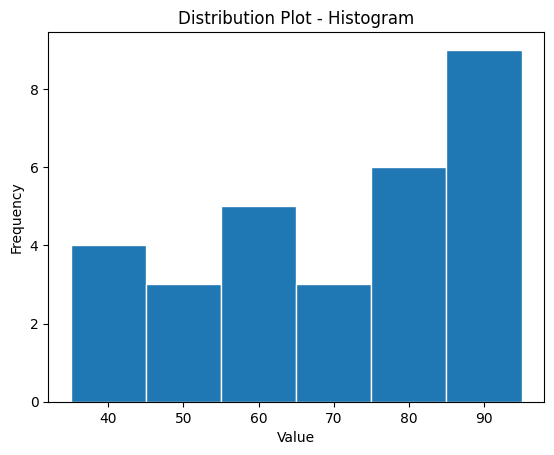

In [6]:
plt.hist(df_student.Marks, ec='white', bins=int(sturges()))
# print()
# print(sturges())
# print(freedman())
# print(scott())
# print()
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Distribution Plot - Histogram')
plt.show()

In [7]:
df_student.Marks.count()

np.int64(30)

In [8]:
import pandas as pd

# Define the classification mapping based on your dataset columns
classification_data = {
    "Column Name": ["Name", "Gender", "Grade", "Marks", "StudyHours", "Attendance"],
    "Measurement Scale": ["Nominal", "Nominal", "Ordinal", "Interval", "Ratio", "Ratio"],
    "Description / Example": [
        "Unique identifiers; text labels with no intrinsic ordering.",
        "Categorical data (M/F) used for grouping with no inherent rank.",
        "Categorical data with a clear intrinsic ranking (A > B > C > D).",
        "Numerical values where differences are meaningful, but lacking a true zero.",
        "Continuous numeric value; 0 hours means an absolute absence of study time.",
        "Percentage value representing physical presence; 0 means no classes attended."
    ]
}

# Create DataFrame
df_classification = pd.DataFrame(classification_data)

# Print the table neatly
print("=================== EXPERIMENT 2: MEASUREMENT SCALES ===================")
print(df_classification.to_string(index=False))

=================== EXPERIMENT 2: MEASUREMENT SCALES ===================
Column Name Measurement Scale                                                         Description / Example
       Name           Nominal                   Unique identifiers; text labels with no intrinsic ordering.
     Gender           Nominal               Categorical data (M/F) used for grouping with no inherent rank.
      Grade           Ordinal              Categorical data with a clear intrinsic ranking (A > B > C > D).
      Marks          Interval   Numerical values where differences are meaningful, but lacking a true zero.
 StudyHours             Ratio    Continuous numeric value; 0 hours means an absolute absence of study time.
 Attendance             Ratio Percentage value representing physical presence; 0 means no classes attended.


In [11]:
df_student.describe()

,StudyHours,Marks,Attendance
count,30.000000,30.0000,30.000000
mean,4.066667,70.2000,75.566667
std,1.998850,18.5944,17.359651
min,1.000000,35.0000,42.000000
25%,2.250000,55.5000,62.250000
50%,4.000000,74.5000,80.000000
75%,6.000000,87.7500,90.750000
max,7.000000,95.0000,99.000000
